# Looking at PUSH data and running it through a detector

In [1]:
import astropy.units as u
import numpy as np

from snewpy.models.ccsn import Wolfe_2023
from snewpy.flavor_transformation import AdiabaticMSW
from snewpy.neutrino import MixingParameters
from snewpy.models.base import PinchedModel, SupernovaModel

## Some plotting functions

In [2]:
import pylab as plt

In [3]:
def plot_quantity(x:u.Quantity, y:u.Quantity, xlabel=None, ylabel=None, **kwargs):
    """Plot the X vs Y array, with given axis labels, adding units"""

    #just in case we are passed bare np.arrays iwthout units
    x = u.Quantity(x)
    y = u.Quantity(y)
    
    if(len(x)==len(y)):
        plt.plot(x.value,y.value,**kwargs)
    else:
        plt.stairs(edges=x.value,values=y.value,**kwargs)
    if xlabel is not None:
        if(not x.unit.is_unity()):
            xlabel+=', '+x.unit._repr_latex_()
        plt.xlabel(xlabel)
    if ylabel is not None:
        if(not y.unit.is_unity()):
            ylabel+=', '+y.unit._repr_latex_()
        plt.ylabel(ylabel)
        
def plot_events(numbers, axis:str='time', **kwargs):
    if axis=='time':
        x = numbers.time.to('s')
        y = numbers.integrate_or_sum('energy').array.squeeze()
    elif axis=='energy':
        x = numbers.energy.to('MeV')
        y = numbers.integrate_or_sum('time').array.squeeze()
    else: 
        raise ValueError(f'axis="{axis}" should be one of "time","energy"')
    plot_quantity(x,y,xlabel=axis.capitalize(), ylabel='Event rate', **kwargs)


In [4]:
#a helper function to calculate total rate
from snewpy.flux import Container
def sum_events(numbers:list):
    res = sum([n.array for n in numbers])
    n = numbers[0]#take first channel as an instance
    return Container(res,n.flavor, n.time, n.energy, integrable_axes=n._integrable_axes)


## Create the neutrino flux at Earth from the model

In [5]:
Wolfe_2023.param

{'progenitor_mass': <Quantity [10.8, 11. , 11.2, 11.4, 11.6, 11.8, 12. , 12.2, 12.4, 12.6,
            12.8, 13. , 13.2, 13.4, 13.6, 13.8, 14. , 14.2, 14.4, 14.6,
            14.8, 15. , 15.2, 15.4, 15.6, 15.8, 16. , 16.2, 16.4, 16.6,
            16.8, 17. , 17.2, 17.4, 17.6, 17.8, 18. , 18.2, 18.4, 18.6,
            18.8, 19. , 19.2, 19.4, 19.6, 19.8, 20. , 20.2, 20.4, 20.6,
            20.8, 21. , 21.2, 21.4, 21.6, 21.8, 22. , 22.2, 22.4, 22.6,
            22.8, 23. , 23.2, 23.4, 23.6, 23.8, 24. , 24.2, 24.4, 24.6,
            24.8, 25. , 25.2, 25.4, 25.6, 25.8, 26. , 26.2, 26.4, 26.6,
            26.8, 27. , 27.2, 27.4, 27.6, 27.8, 28. , 28.2, 29. , 30. ,
            31. , 32. , 33. , 34. , 35. , 36. , 37. , 38. , 39. , 40. ] solMass>,
 'eos': ['SFHo', 'SFHx', 'DD2', 'BHB', 'TM1', 'NL3'],
 'callibration': ['calI']}

In [6]:
# prepare the neutrino flux from the model
model = Wolfe_2023(progenitor_mass=27.6*u.solMass,eos='SFHo') # SN model
transformation = AdiabaticMSW(MixingParameters('NORMAL')) # Desired flavor transformation

times    = model.get_time()
energies = np.linspace(0,60,601)<<u.MeV
distance = 10*u.kpc

#get the flux from the model
flux = model.get_flux(t=times, E=energies, distance=distance, flavor_xform=transformation)
fluence = flux.integrate('time')


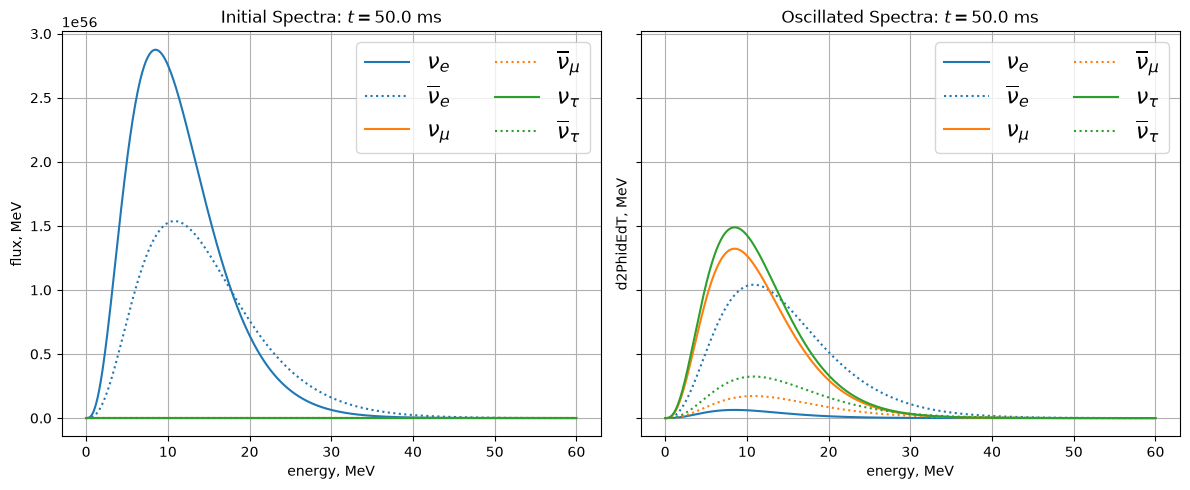

In [7]:
t = 50*u.ms

ispec = model.get_initial_spectra(t, energies)
ospec_nmo = model.get_transformed_spectra(t, energies, transformation)

fig, axes = plt.subplots(1,2, figsize=(12,5), sharex=True, sharey=True, tight_layout=True)

for i, spec in enumerate([ispec, ospec_nmo]):
    ax = axes[i]
    plt.sca(ax)
    spec.plot('energy')
    
    ax.set(title='Initial Spectra: $t = ${:.1f}'.format(t) if i==0 else 'Oscillated Spectra: $t = ${:.1f}'.format(t))
    ax.grid()
    ax.legend(loc='upper right', ncol=2, fontsize=16)

ax = axes[0]
ax.set(ylabel=r'flux, MeV')

fig.tight_layout();

## Using a detector config from SNOwGLoBES

In [8]:
from snewpy.rate_calculator import RateCalculator

#load the RateCalculator object
rc = RateCalculator()

### List available detectors

In [9]:
#list available detectors
list(rc.detectors)

['wc100kt30prct',
 'wc100kt15prct',
 'ar40kt',
 'scint20kt',
 'halo1',
 'halo2',
 'novaND',
 'novaFD',
 'wc100kt30prct_he',
 'ar40kt_he',
 'icecube',
 'km3net',
 'ds20',
 'argo',
 'lz',
 'xent',
 'pandax']

### Read the detector you need

In [10]:
#read the detector
detector = rc.read_detector('ar40kt')
detector

Detector(name="ar40kt", mass=40.0 kt, channels=['nue_e', 'nuebar_e', 'numu_e', 'numubar_e', 'nutau_e', 'nutaubar_e', 'nue_Ar40', 'nuebar_Ar40', 'nc_nue_Ar40', 'nc_numu_Ar40', 'nc_nutau_Ar40', 'nc_nuebar_Ar40', 'nc_numubar_Ar40', 'nc_nutaubar_Ar40'])

### Inspecting the detector

In [11]:
#list all the channels
detector.channels

{'nue_e': DetectionChannel (flavor=NU_E, smearing=True, weight=0.45),
 'nuebar_e': DetectionChannel (flavor=NU_E_BAR, smearing=True, weight=0.45),
 'numu_e': DetectionChannel (flavor=NU_MU, smearing=True, weight=0.45),
 'numubar_e': DetectionChannel (flavor=NU_MU_BAR, smearing=True, weight=0.45),
 'nutau_e': DetectionChannel (flavor=NU_TAU, smearing=True, weight=0.45),
 'nutaubar_e': DetectionChannel (flavor=NU_TAU_BAR, smearing=True, weight=0.45),
 'nue_Ar40': DetectionChannel (flavor=NU_E, smearing=True, weight=0.025),
 'nuebar_Ar40': DetectionChannel (flavor=NU_E_BAR, smearing=True, weight=0.025),
 'nc_nue_Ar40': DetectionChannel (flavor=NU_E, smearing=True, weight=0.025),
 'nc_numu_Ar40': DetectionChannel (flavor=NU_MU, smearing=True, weight=0.025),
 'nc_nutau_Ar40': DetectionChannel (flavor=NU_TAU, smearing=True, weight=0.025),
 'nc_nuebar_Ar40': DetectionChannel (flavor=NU_E_BAR, smearing=True, weight=0.025),
 'nc_numubar_Ar40': DetectionChannel (flavor=NU_MU_BAR, smearing=True, 

### Running the rate calculation

C:\Users\jpknelle\AppData\Roaming\Python\Python312\site-packages\snewpy\rate_calculator.py:353: RuntimeWarning: divide by zero encountered in log
  return np.interp(np.log(E)/np.log(10), xp, yp, left=0, right=0)*E*1e-38 <<u.cm**2


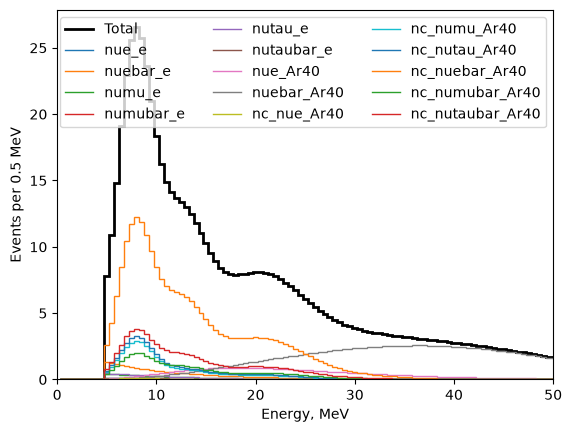

In [12]:
events = detector.run(fluence, detector_effects=True)

plot_events(sum_events(list(events.values())), axis='energy', label='Total', lw=2, color='k')
for chan,numbers in events.items():
    plot_events(numbers, axis='energy', label=chan)

plt.legend(ncols=3)
plt.ylabel(f'Events per {numbers.energy.diff()[0]<<u.MeV}')
plt.xlim(0,50)
plt.show()

In [13]:
# Compute number of events in all interaction channels
total_events  = sum([chan.integrate_or_sum('energy').array.squeeze().value for chan in events.values()])        

print("Total events in detector (with smearing):" , total_events)

Total events in detector (with smearing): 686.0162726363208
